In [1]:
import torch

SEED = 1234
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# 0. Choosing "teacher" model

In [2]:
checkpoint = "bert-base-uncased"
task_name  = "cola"

# 1. Loading our mrpc part of the GLUE dataset

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

raw_datasets = load_dataset("glue", task_name)
tokenizer = AutoTokenizer.from_pretrained(checkpoint)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 8551
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1043
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1063
    })
})

In [5]:
raw_datasets['train']

Dataset({
    features: ['sentence', 'label', 'idx'],
    num_rows: 8551
})

In [6]:
from datasets import DatasetDict

In [7]:
raw_datasets = DatasetDict({
    "train": raw_datasets['train'],
    "validation": raw_datasets['validation'],
    "test": raw_datasets['test']
})

In [8]:
raw_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 8551
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1043
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx'],
        num_rows: 1063
    })
})

In [9]:
raw_train_dataset = raw_datasets["train"]
raw_train_dataset[0]

{'sentence': "Our friends won't buy this analysis, let alone the next one we propose.",
 'label': 1,
 'idx': 0}

In [10]:
raw_train_dataset[5]['sentence']

"I'll fix you a drink."

In [11]:
raw_train_dataset[5]['label']

1

In [12]:
raw_train_dataset[5]['idx']

5

In [13]:
raw_train_dataset.features

{'sentence': Value('string'),
 'label': ClassLabel(names=['unacceptable', 'acceptable']),
 'idx': Value('int32')}

# 2. Preprocess

In [14]:
def tokenize_function(example):
    return tokenizer(example["sentence"], truncation=True)

tokenized_datasets = raw_datasets.map(tokenize_function, batched=True)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 8551
    })
    validation: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1043
    })
    test: Dataset({
        features: ['sentence', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1063
    })
})

# 3. Preparing for Training

In [15]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [16]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence", "idx"])
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets.set_format("torch")
tokenized_datasets["train"].column_names

['labels', 'input_ids', 'token_type_ids', 'attention_mask']

In [17]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    tokenized_datasets["train"], shuffle=True, batch_size=32, collate_fn=data_collator
)

val_dataloader = DataLoader(
    tokenized_datasets["validation"], batch_size=32, collate_fn=data_collator
)

eval_dataloader = DataLoader(
    tokenized_datasets["test"], batch_size=32, collate_fn=data_collator
)

In [18]:
for batch in train_dataloader:
    break
{k: v.shape for k, v in batch.items()}

{'labels': torch.Size([32]),
 'input_ids': torch.Size([32, 19]),
 'token_type_ids': torch.Size([32, 19]),
 'attention_mask': torch.Size([32, 19])}

# 4. Loading model

In [19]:
import sys
sys.path.insert(0, '../')

In [20]:
from Bert_model.modeling_bert import BertForSequenceClassification

In [21]:
# id2label, label2id dicts for the outputs for the model
labels = tokenized_datasets["train"].features["labels"].names
num_labels = len(labels)
label2id, id2label = dict(), dict()
for i, label in enumerate(labels):
    label2id[label] = str(i)
    id2label[str(i)] = label

In [22]:
model = BertForSequenceClassification.from_pretrained(
    checkpoint,
    num_labels=num_labels,
    id2label=id2label,
    label2id=label2id,
    output_hidden_states=True,
    output_attentions=True
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [23]:
model.set_use_module_grafting(False)
model.set_use_scc_status(False)

In [24]:
outputs = model(**batch)
print(outputs.loss, outputs.logits.shape)

tensor(0.8448, grad_fn=<NllLossBackward0>) torch.Size([32, 2])


In [25]:
device = torch.device("cuda:1") if torch.cuda.is_available() else torch.device("cpu")
model.to(device)

device

device(type='cuda', index=1)

In [26]:
from train_eval_func import eval_loop

In [27]:
eval_loop(model, val_dataloader, task_name, device)

({'matthews_correlation': -0.049848138106847704}, 0.9240047570430872)

# 5. Learning Rate and Leanring Scheduler Setup

In [28]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=3e-5)

In [29]:
from train_eval_func import set_lr_scheduler

num_epochs = 10
num_training_steps = num_epochs * len(train_dataloader)

lr_scheduler = set_lr_scheduler(
    optimizer          = optimizer,
    num_training_steps = num_training_steps
)

print(num_training_steps)

2680


In [30]:
patience=5
save_path=f'./weights/bert-{task_name}.pt'

# 6. Training

In [31]:
from train_eval_func import train

In [32]:
train_stats = train(
    model,
    train_dataloader,
    val_dataloader,
    task_name,
    device,
    num_epochs=num_epochs,
    lr=lr_scheduler,
    patience=patience,
    use_early_stopping=True,
    optimizer=optimizer,
    lr_scheduler=lr_scheduler,
    save_path=save_path,
    display_epoch_iter=True
)

Training:   0%|          | 0/2680 [00:00<?, ?it/s]/home/abhinavl/work/Layer_Graft/layer-grafting-publication/glue_fine_tune/../train_eval_func.py:196: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  total_loss += float(loss)
Training:  10%|█         | 268/2680 [00:28<02:41, 14.96it/s]

✓ Saved checkpoint (best loss: 0.4279)

<----------------- Epoch 1 ----------------->
Loss: 0.49, Training Metrics:
  matthews_correlation: 0.4097
Validation Loss: 0.43, Validation Metrics:
  matthews_correlation: 0.5289
Elapsed Time: 15.8723 sec


Training:  20%|██        | 536/2680 [00:54<01:39, 21.61it/s]  

✓ Saved checkpoint (best loss: 0.4411)

<----------------- Epoch 2 ----------------->
Loss: 0.28, Training Metrics:
  matthews_correlation: 0.7357
Validation Loss: 0.44, Validation Metrics:
  matthews_correlation: 0.5547
Elapsed Time: 14.2573 sec


Training:  30%|███       | 804/2680 [01:20<01:23, 22.45it/s]

...


<----------------- Epoch 8 ----------------->
Loss: 0.04, Training Metrics:
  matthews_correlation: 0.9809
Validation Loss: 1.46, Validation Metrics:
  matthews_correlation: 0.5899
Elapsed Time: 14.0506 sec


Training:  90%|█████████ | 2412/2680 [02:56<00:12, 21.91it/s]


<----------------- Epoch 9 ----------------->
Loss: 0.04, Training Metrics:
  matthews_correlation: 0.9840
Validation Loss: 1.57, Validation Metrics:
  matthews_correlation: 0.5833
Elapsed Time: 14.125 sec


Training: 100%|██████████| 2680/2680 [03:11<00:00, 13.99it/s]


<----------------- Epoch 10 ----------------->
Loss: 0.02, Training Metrics:
  matthews_correlation: 0.9891
Validation Loss: 1.56, Validation Metrics:
  matthews_correlation: 0.5861
Elapsed Time: 14.2221 sec

Total Training Time: 191.62 sec
Chosen Primary Metric: matthews_correlation
Best Metric Run: 0.6016


### Plotting Loss

In [33]:
from train_eval_func import plotLoss, plotAccuracy

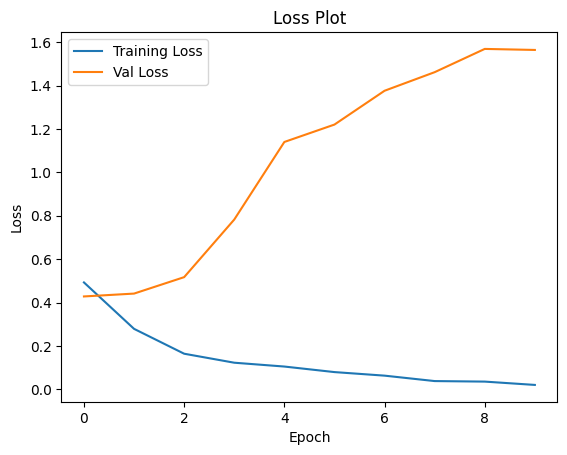

In [34]:
plotLoss(train_stats['train_losses'], train_stats['val_losses'], title="Loss Plot")

### Plotting Accuracy

In [35]:
def getMetricList(train_stats, metric_name='accuracy'):
    train_values = [m[metric_name] for m in train_stats['train_metrics_history']]
    val_values = [m[metric_name] for m in train_stats['val_metrics_history']]

    return train_values, val_values

In [36]:
train_values, val_values = getMetricList(train_stats, 'matthews_correlation')

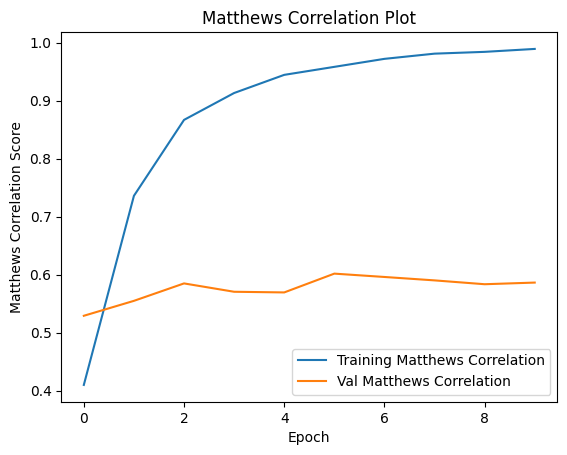

In [37]:
plotAccuracy(train_values, val_values, legend=["Training Matthews Correlation", "Val Matthews Correlation"], title="Matthews Correlation Plot", ylabel="Matthews Correlation Score")

# 7. Evaluation

In [38]:
best_weight = torch.load(save_path)

In [39]:
model.load_state_dict(best_weight['model_state_dict'])

<All keys matched successfully>

In [40]:
eval_loop(model, val_dataloader, task_name, device)[0]

{'matthews_correlation': 0.6015805476045657}